<a href="https://colab.research.google.com/github/kevinfaithbilla/Data-Science-and-Machine-Learning/blob/main/Consumer%20Complaint%20Resolution%20Using%20Python%20and%20Machine%20Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Mini Project:2 Conumer complaint resloition using python**

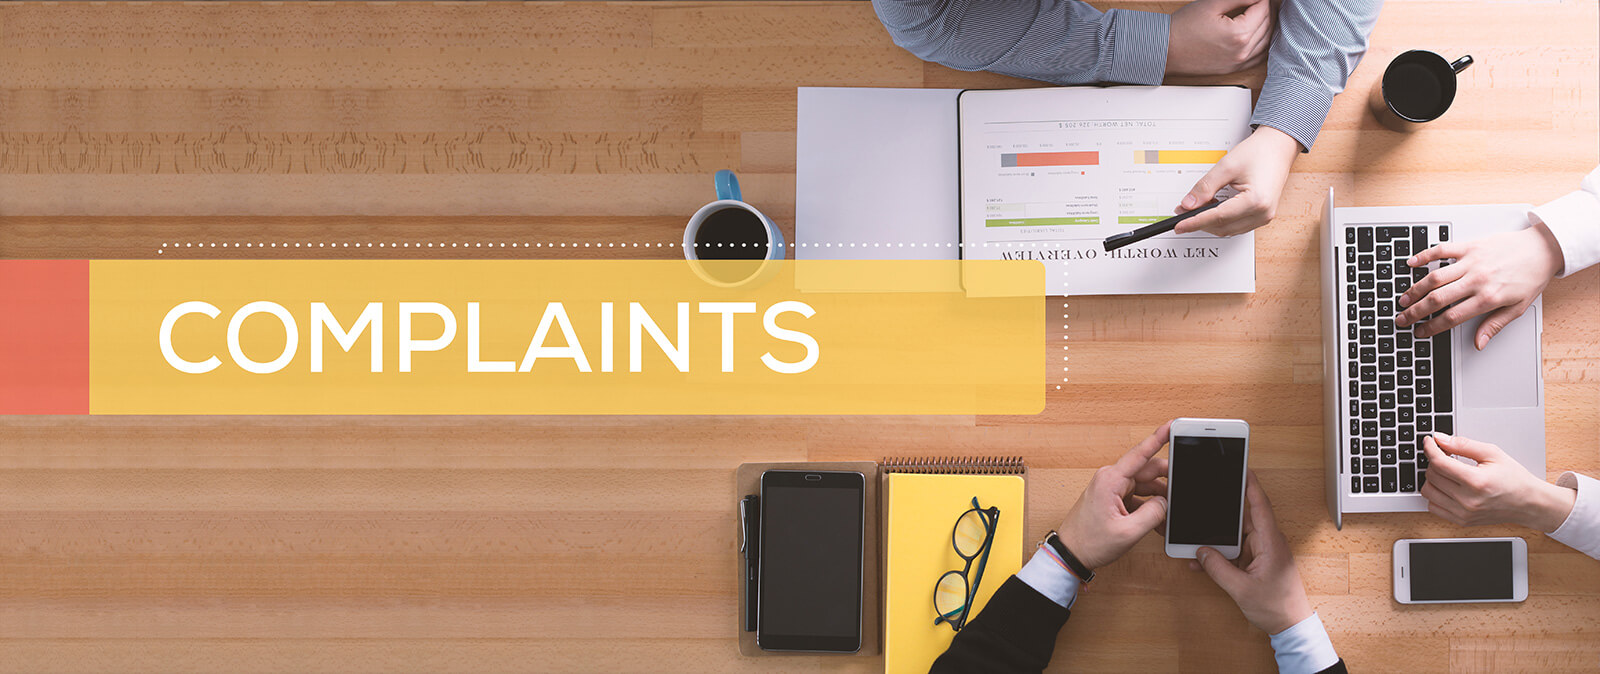

Take the Reference for this Project<br>
https://ashwin-ks.github.io/2018-08-15-NLP-Consumer-Complaints-Classification-ML-DL/


**Scenario:**<br>
Product review is the most basic function/factor in resolvingcustomerissues and increasingthe sales growth of any product.Wecan understandtheir mindset toward our service withoutasking each customer.
<br>When consumers are unhappywith some aspect of a business, they reach out to customer service and might raise a complaint. Companiestry their best to resolve the complaints that they receive. However, it might not always be possible to appease every customer.So Here, we will analyze data, and with the help ofdifferent algorithms, we are finding the best classification of customer category so that we can predict our test data.<br>
<br>**Objective:** <br>
Use Python libraries such as Pandas for data operations, Seaborn and Matplotlib for data visualization and EDA tasks, Sklearn for model building and performance visualization, andbased on the best model,make a prediction for the test file and save the output.<br>
<br>The main objective is to predict whetherour customer is disputedor not with the help of given data.<br>
<br>**Dataset description:**
<br>Customersfaced some issuesand triedto report their problems to customer care.<br>
<br>**•Dispute:** This is our target variable based on train data; wehave two groups, one with a dispute with the bank.
<br>**•Date received:** The day complaint was received.<br>
**•Sub-product:** loan, insurance, other mortgage options<br>
**•Issue:** Complaint of customers<br>
**•Company public response:** Company’s response to consumer complaint<br>
**•Company:** Company name<br>
**•State:** State where the customer lives (different state of USA)<br>
**•ZIP code:** Where the customer lives<br>
**•Submitted via:** Register complaints via different platforms (online web, phone, referral, fax, post mail)<br>
**•Date sent to company:** The day complaint was registered<br>
**•Timely response?:** Yes/no<br>
**•Consumer disputed?:** yes/no (target variable)<br>Complaint ID: unique to each consumer.

In [ ]:
#imorting the Labraries
!pip install -U nltk scikit-learn xgboost

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import string

import nltk
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')     # required by newer nltk tokenizers
nltk.download('wordnet')
nltk.download('omw-1.4')

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer, PorterStemmer
from nltk.tokenize import wordpunct_tokenize

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from xgboost import XGBClassifier


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 20.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 107.3 MB/s eta 0:00:00
  Attempting uninstall: nltk
    Found existing installation: nltk 3.9.1
    Uninstalling nltk-3.9.1:
      Successfully uninstalled nltk-3.9.1
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


In [ ]:
!wget "https://media.githubusercontent.com/media/raviagrawal121/Consumaer_Complaint_resolution/main/Consumer_Complaints_train.csv"
!wget "https://raw.githubusercontent.com/raviagrawal121/Consumaer_Complaint_resolution/main/Consumer_Complaints_test.csv"

--2026-07-08 06:37:01--  https://media.githubusercontent.com/media/raviagrawal121/Consumaer_Complaint_resolution/main/Consumer_Complaints_train.csv
Resolving media.githubusercontent.com (media.githubusercontent.com)... 185.199.109.133, 185.199.108.133, 185.199.111.133, ...
Connecting to media.githubusercontent.com (media.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 129180717 (123M) [text/plain]
Saving to: ‘Consumer_Complaints_train.csv’

Consumer_Complaints 100%[===================>] 123.20M   179MB/s    in 0.7s    

2026-07-08 06:37:01 (179 MB/s) - ‘Consumer_Complaints_train.csv’ saved [129180717/129180717]

--2026-07-08 06:37:02--  https://raw.githubusercontent.com/raviagrawal121/Consumaer_Complaint_resolution/main/Consumer_Complaints_test.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubuse

In [ ]:
#•Read the Data from the Given excel file
train_data = pd.read_csv('/content/Consumer_Complaints_train.csv', engine='python')
test_data = pd.read_csv('/content/Consumer_Complaints_test.csv')

In [ ]:
train_data.head()

,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Consumer consent provided?,Submitted via,Date sent to company,Company response to consumer,Timely response?,Consumer disputed?,Complaint ID
0,2015-10-14,Credit reporting,NaN,Incorrect information on credit report,Information is not mine,NaN,NaN,Equifax,GA,30134,NaN,Consent not provided,Web,2015-10-14,Closed with explanation,Yes,No,1605653
1,2015-04-26,Bank account or service,Other bank product/service,Deposits and withdrawals,NaN,RE : XXXX XXXX XXXX-PRIVILEGED AND CONFIDENTIA...,NaN,Wells Fargo & Company,GA,319XX,NaN,Consent provided,Web,2015-04-26,Closed with explanation,Yes,Yes,1347613
2,2013-12-20,Credit card,NaN,Other,NaN,NaN,NaN,Citibank,SC,29203,NaN,NaN,Phone,2014-01-03,Closed with non-monetary relief,Yes,No,640394
3,2016-03-03,Debt collection,"Other (i.e. phone, health club, etc.)",Disclosure verification of debt,Not given enough info to verify debt,NaN,Company has responded to the consumer and the ...,"FAIR COLLECTIONS & OUTSOURCING, INC.",OH,43082,NaN,NaN,Referral,2016-03-04,Closed with explanation,Yes,No,1815134
4,2015-01-30,Debt collection,Medical,Disclosure verification of debt,Not given enough info to verify debt,NaN,NaN,"HCFS Health Care Financial Services, Inc.",CA,90036,NaN,NaN,Web,2015-01-30,Closed with explanation,Yes,Yes,1218613


In [ ]:
test_data.head()

,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Consumer consent provided?,Submitted via,Date sent to company,Company response to consumer,Timely response?,Complaint ID
0,2015-01-17,Credit card,NaN,Customer service / Customer relations,NaN,NaN,NaN,Citibank,TX,75241,NaN,NaN,Web,2015-01-17,Closed with monetary relief,Yes,1198133
1,2016-06-22,Consumer Loan,Title loan,Payment to acct not credited,NaN,NaN,Company believes it acted appropriately as aut...,"Larsen MacColl Partners II, L.P.",TX,76548,Servicemember,NaN,Phone,2016-06-22,Closed with explanation,Yes,1979989
2,2015-09-04,Credit card,NaN,Credit line increase/decrease,NaN,I WANT TO REQUEST A CREDIT LINE INCREASE OF XX...,NaN,Capital One,NC,271XX,NaN,Consent provided,Web,2015-09-04,Closed with explanation,Yes,1552090
3,2016-05-17,Consumer Loan,Installment loan,Problems when you are unable to pay,NaN,I have asked One Main Financial not to call my...,NaN,"OneMain Financial Holdings, LLC",MO,634XX,NaN,Consent provided,Web,2016-05-20,Closed with non-monetary relief,Yes,1929306
4,2016-07-07,Debt collection,"Other (i.e. phone, health club, etc.)",Improper contact or sharing of info,Contacted employer after asked not to,I have received several calls from a XXXX XXXX...,Company has responded to the consumer and the ...,"GMA Investments, LLC",SC,296XX,NaN,Consent provided,Web,2016-07-07,Closed with explanation,Yes,2001667


In [ ]:
#•print shape of train and test datasets
print("Train :\n\n",train_data.dtypes)
print("Test :\n",test_data.dtypes)


Train :

 Date received                   object
Product                         object
Sub-product                     object
Issue                           object
Sub-issue                       object
Consumer complaint narrative    object
Company public response         object
Company                         object
State                           object
ZIP code                        object
Tags                            object
Consumer consent provided?      object
Submitted via                   object
Date sent to company            object
Company response to consumer    object
Timely response?                object
Consumer disputed?              object
Complaint ID                     int64
dtype: object
Test :
 Date received                   object
Product                         object
Sub-product                     object
Issue                           object
Sub-issue                       object
Consumer complaint narrative    object
Company public response         

In [ ]:
#printing shapes of train and test datasets
print("Train",train_data.shape)
print("Test",test_data.shape)

Train (358810, 18)
Test (119606, 17)


In [ ]:
#printing columns of train and test datasets shape
print("Train",train_data.columns)
print("Test",test_data.columns)


Train Index(['Date received', 'Product', 'Sub-product', 'Issue', 'Sub-issue',
       'Consumer complaint narrative', 'Company public response', 'Company',
       'State', 'ZIP code', 'Tags', 'Consumer consent provided?',
       'Submitted via', 'Date sent to company', 'Company response to consumer',
       'Timely response?', 'Consumer disputed?', 'Complaint ID'],
      dtype='object')
Test Index(['Date received', 'Product', 'Sub-product', 'Issue', 'Sub-issue',
       'Consumer complaint narrative', 'Company public response', 'Company',
       'State', 'ZIP code', 'Tags', 'Consumer consent provided?',
       'Submitted via', 'Date sent to company', 'Company response to consumer',
       'Timely response?', 'Complaint ID'],
      dtype='object')


In [ ]:
#printing the missing values
filter_train_data=pd.DataFrame({'Count':train_data.isnull().sum(),'Percentage':train_data.isnull().sum()/train_data.shape[0]})
filter_test_data =pd.DataFrame({'Count':test_data.isnull().sum(),'Percentage':train_data.isnull().sum()/test_data.shape[0]})
print("Train\n\n\n",filter_train_data)
print("Test",filter_test_data)

Train


                                Count  Percentage
Date received                      0    0.000000
Product                            0    0.000000
Sub-product                   103786    0.289251
Issue                              0    0.000000
Sub-issue                     219374    0.611393
Consumer complaint narrative  302630    0.843427
Company public response       290879    0.810677
Company                            0    0.000000
State                           2903    0.008091
ZIP code                        2911    0.008113
Tags                          308584    0.860021
Consumer consent provided?    257230    0.716898
Submitted via                      0    0.000000
Date sent to company               0    0.000000
Company response to consumer       0    0.000000
Timely response?                   0    0.000000
Consumer disputed?                 0    0.000000
Complaint ID                       0    0.000000
Test                                  Count  Percentage
Comp

In [ ]:
#Dropcolumns where more than 25% of data are missing
train_data.drop(['Sub-product','Sub-issue','Consumer complaint narrative','Company public response','Tags','Consumer consent provided?'],axis=1,inplace=True)
test_data.drop(['Sub-product','Sub-issue','Consumer complaint narrative','Company public response','Tags','Consumer consent provided?'],axis=1,inplace=True)

In [ ]:
#•Extracting Day, Month,and Year from Date Received Column and create new fields for a month, year,and day
from datetime import date as dt

#train_data dataset
train_data_date = train_data['Date received']
train_data['Year']=pd.DatetimeIndex(train_data['Date received']).year
train_data['Month']=pd.DatetimeIndex(train_data['Date received']).month
train_data['day']=pd.DatetimeIndex(train_data['Date received']).day

#test_data dataset
test_data_date = test_data['Date received']
test_data['Year']=pd.DatetimeIndex(test_data['Date received']).year
test_data['Month']=pd.DatetimeIndex(test_data['Date received']).month
test_data['day']=pd.DatetimeIndex(test_data['Date received']).day

#converting to datatime type
train_data[['Date received','Date sent to company']]=train_data[['Date received','Date sent to company']].apply(pd.to_datetime)
test_data[['Date received','Date sent to company']]=test_data[['Date received','Date sent to company']].apply(pd.to_datetime)


In [ ]:
#•Calculate the Number of Days the Complaint was with the Company and create a new field as “Days held”
train_data['Days held']=(train_data['Date sent to company']-train_data['Date received']).dt.days
test_data['Days held']=(test_data['Date sent to company']-test_data['Date received']).dt.days

train_data['Days held']=train_data['Days held'].astype(int)
test_data['Days held']=test_data['Days held'].astype(int)

In [ ]:
#•Drop "Date Received","Date Sent to Company","ZIP Code", "Complaint ID"fields
train_data.drop(['Date received','Date sent to company','ZIP code','Complaint ID'],axis=1,inplace=True)
test_data.drop(['Date received','Date sent to company','ZIP code','Complaint ID'],axis=1,inplace=True)

In [ ]:
#•Finding the mode for “State”
print('Train\n\n',train_data['State'].mode())
print('Train\n\n',train_data['State'].mode())

Train

 0    CA
Name: State, dtype: object
Train

 0    CA
Name: State, dtype: object


In [ ]:
#•Imputing Nullvalue in “State”by Mode
train_data['State'].fillna('CA',inplace=True)
test_data['State'].fillna('CA',inplace=True)

/tmp/ipykernel_1365/2080295908.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_data['State'].fillna('CA',inplace=True)
/tmp/ipykernel_1365/2080295908.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try usi

In [ ]:
#checking the null values
print('Train\n\n',train_data.isnull().sum())
print('Train\n\n',train_data.isnull().sum())

Train

 Product                         0
Issue                           0
Company                         0
State                           0
Submitted via                   0
Company response to consumer    0
Timely response?                0
Consumer disputed?              0
Year                            0
Month                           0
day                             0
Days held                       0
dtype: int64
Train

 Product                         0
Issue                           0
Company                         0
State                           0
Submitted via                   0
Company response to consumer    0
Timely response?                0
Consumer disputed?              0
Year                            0
Month                           0
day                             0
Days held                       0
dtype: int64


In [ ]:
#With the help of the days we calculated above,create a newfield 'Week_Received'where we calculate the week based on the day of receiving.
train_data['Week_Received'] = pd.DatetimeIndex(train_data_date).isocalendar().week.values
test_data['Week_Received'] = pd.DatetimeIndex(test_data_date).isocalendar().week.values



In [ ]:
train_data.head()


,Product,Issue,Company,State,Submitted via,Company response to consumer,Timely response?,Consumer disputed?,Year,Month,day,Days held,Week_Received
0,Credit reporting,Incorrect information on credit report,Equifax,GA,Web,Closed with explanation,Yes,No,2015,10,14,0,42
1,Bank account or service,Deposits and withdrawals,Wells Fargo & Company,GA,Web,Closed with explanation,Yes,Yes,2015,4,26,0,17
2,Credit card,Other,Citibank,SC,Phone,Closed with non-monetary relief,Yes,No,2013,12,20,14,51
3,Debt collection,Disclosure verification of debt,"FAIR COLLECTIONS & OUTSOURCING, INC.",OH,Referral,Closed with explanation,Yes,No,2016,3,3,1,9
4,Debt collection,Disclosure verification of debt,"HCFS Health Care Financial Services, Inc.",CA,Web,Closed with explanation,Yes,Yes,2015,1,30,0,5


In [ ]:
test_data.head()

,Product,Issue,Company,State,Submitted via,Company response to consumer,Timely response?,Year,Month,day,Days held,Week_Received
0,Credit card,Customer service / Customer relations,Citibank,TX,Web,Closed with monetary relief,Yes,2015,1,17,0,3
1,Consumer Loan,Payment to acct not credited,"Larsen MacColl Partners II, L.P.",TX,Phone,Closed with explanation,Yes,2016,6,22,0,25
2,Credit card,Credit line increase/decrease,Capital One,NC,Web,Closed with explanation,Yes,2015,9,4,0,36
3,Consumer Loan,Problems when you are unable to pay,"OneMain Financial Holdings, LLC",MO,Web,Closed with non-monetary relief,Yes,2016,5,17,3,20
4,Debt collection,Improper contact or sharing of info,"GMA Investments, LLC",SC,Web,Closed with explanation,Yes,2016,7,7,0,27


In [ ]:
#•store data of disputed people into the “disputed_cons” variable for future tasks
disputed_cons = train_data[train_data['Consumer disputed?']=='Yes']

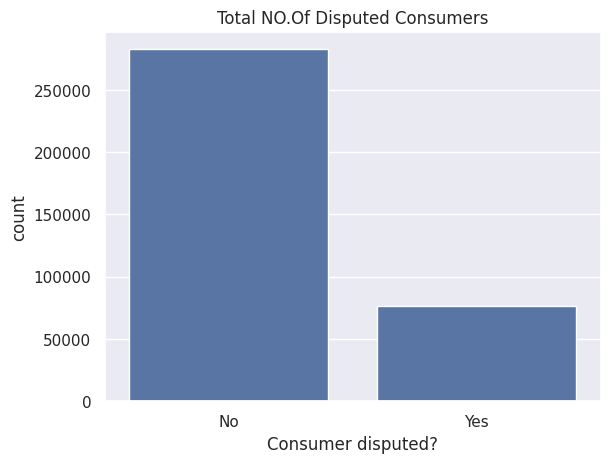

In [ ]:
#•Plot bar graph of thetotal no of disputes of consumers with the help of seaborn
sns.set_theme(style="darkgrid")
plt.title("Total NO.Of Disputed Consumers")
sns.countplot(x=train_data['Consumer disputed?'])
plt.show()

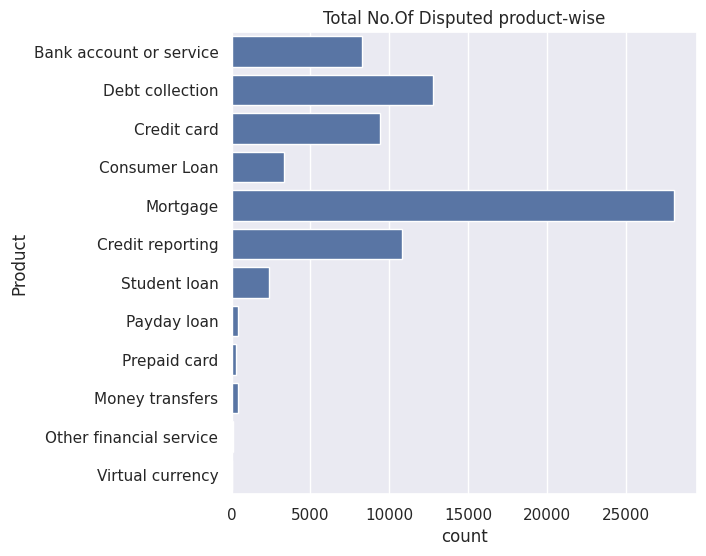

In [ ]:
#•Plot bar graph of the total no of disputes products-wise with the help ofseaborn
plt.figure(figsize=(6,6))
plt.title('Total No.Of Disputed product-wise')
sns.countplot(data=disputed_cons,y='Product')
plt.show()

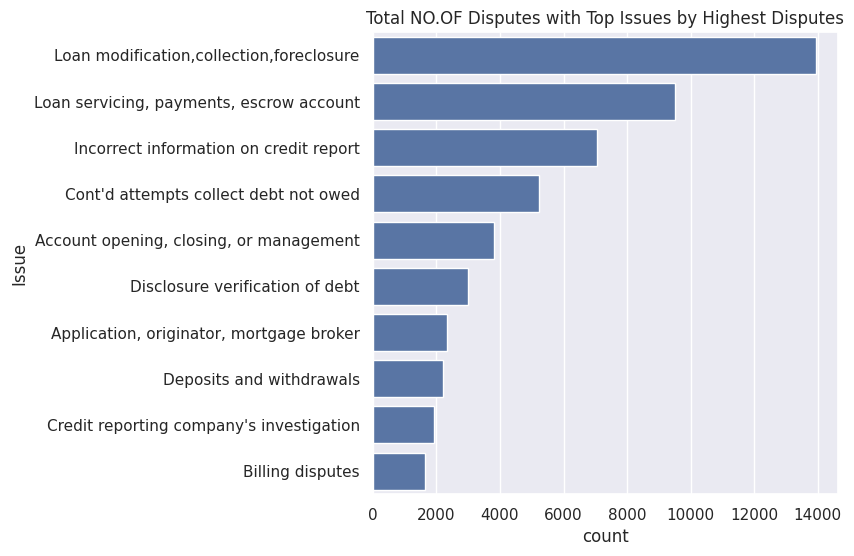

In [ ]:
#•Plot bar graph ofthe total no of disputes with Top Issues by Highest Disputes, with the help ofseaborn
plt.figure(figsize=(6,6))
plt.title('Total NO.OF Disputes with Top Issues by Highest Disputes')
sns.countplot(data=disputed_cons,y='Issue',order=disputed_cons.Issue.value_counts().iloc[:10].index)
plt.show()

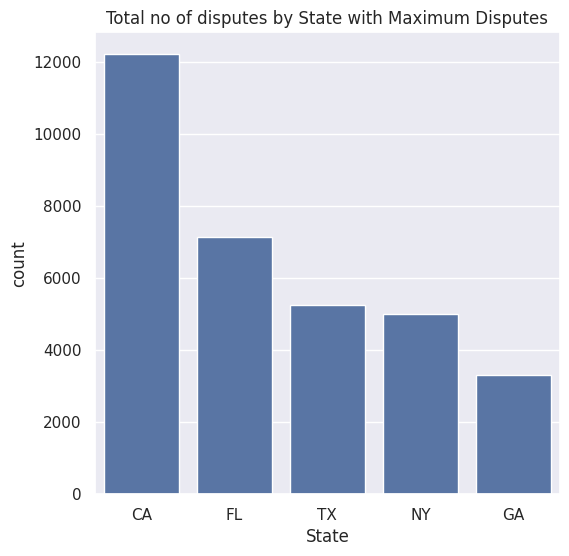

In [ ]:
#•Plot bar graph ofthe total no of disputes by State with Maximum Disputes
plt.figure(figsize=(6,6))
plt.title('Total no of disputes by State with Maximum Disputes')
sns.countplot(data=disputed_cons,x='State',order=disputed_cons.State.value_counts().iloc[:5].index)
plt.show()


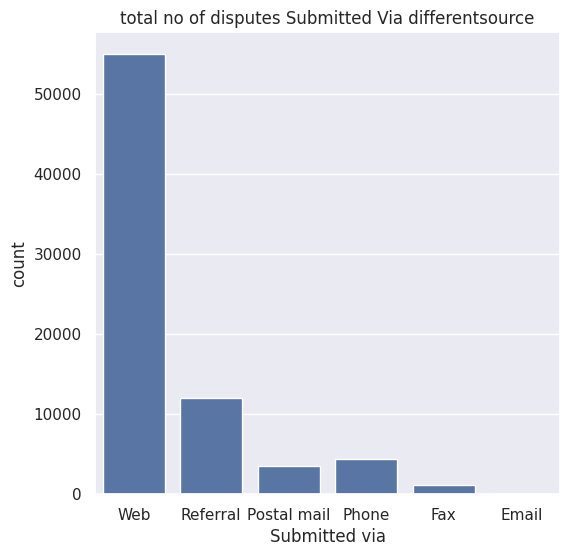

In [ ]:
#•Plotbar graph ofthe total no of disputes Submitted Via differentsource
plt.figure(figsize=(6,6))
plt.title('total no of disputes Submitted Via differentsource')
sns.countplot(data=disputed_cons,x='Submitted via')
plt.show()

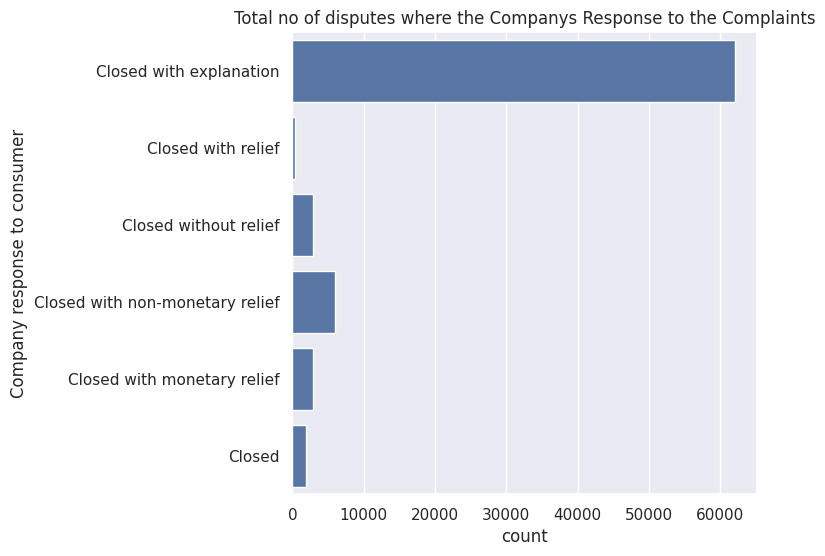

In [ ]:
#•Plot bar graph ofthe total no of disputes where the Company's Response to the Complaints
plt.figure(figsize=(6,6))
plt.title('Total no of disputes where the Companys Response to the Complaints')
sns.countplot(data=disputed_cons,y='Company response to consumer')
plt.show()

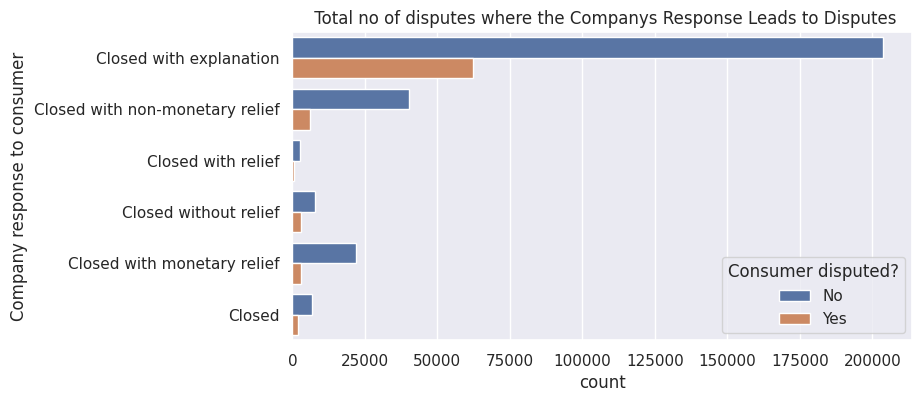

In [ ]:
#•Plot bar graph ofthe total no of disputes where the Company's Response Leadsto Disputes
plt.figure(figsize=(8,4))
plt.title(' Total no of disputes where the Companys Response Leads to Disputes')
sns.countplot(data=train_data,y='Company response to consumer',hue = "Consumer disputed?")
plt.show()

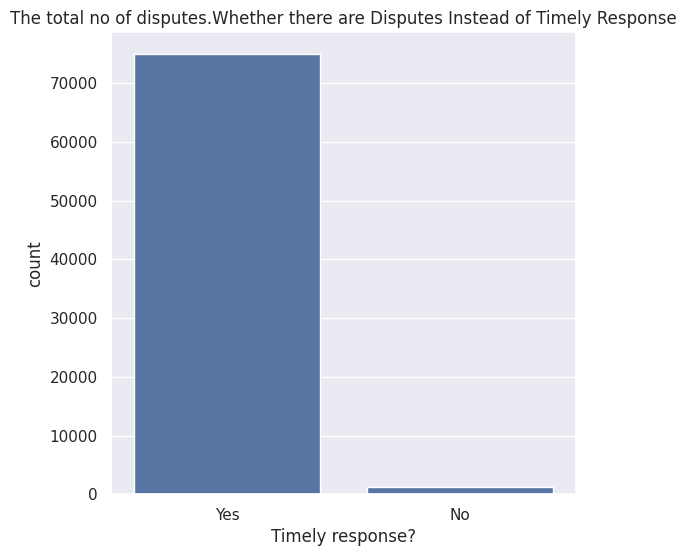

In [ ]:
#•Plot bar graph ofthe total no of disputes.Whether there are Disputes Instead of Timely Response
plt.figure(figsize=(6,6))
plt.title('The total no of disputes.Whether there are Disputes Instead of Timely Response')
sns.countplot(data=disputed_cons,x='Timely response?')
plt.show()


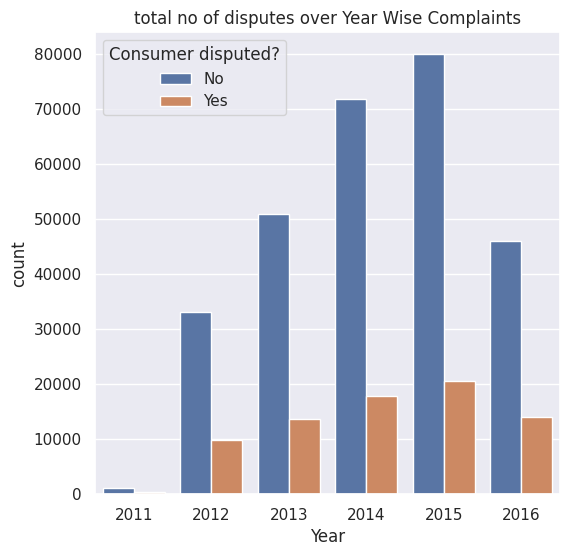

In [ ]:
#•Plot bar graph ofthe total no of disputes over Year Wise Complaints
plt.figure(figsize=(6,6))
plt.title('total no of disputes over Year Wise Complaints')
sns.countplot(data=train_data,x='Year',hue='Consumer disputed?')
plt.show()



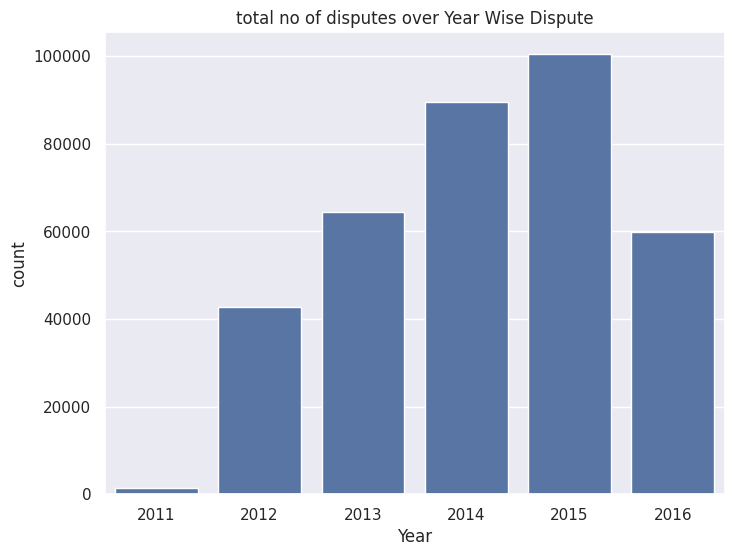

In [ ]:
#•Plot bar graph ofthe total no of disputes over Year Wise Dispute
plt.figure(figsize=(8,6))
plt.title('total no of disputes over Year Wise Dispute')
sns.countplot(data=train_data,x='Year')
plt.show()


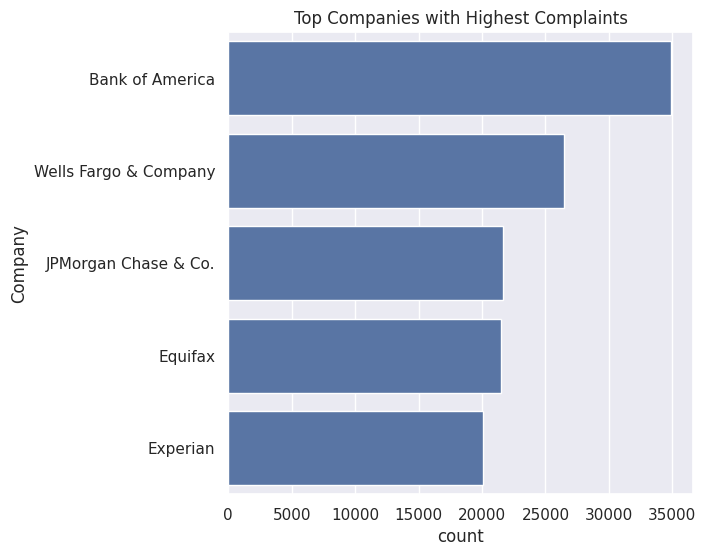

In [ ]:
#•Plot bar graph ofTop Companies with Highest Complaints
plt.figure(figsize=(6,6))
plt.title('Top Companies with Highest Complaints')
sns.countplot(data=train_data,y='Company',order=train_data.Company.value_counts().iloc[:5].index)
plt.show()


In [ ]:
#•Converte all negative days held to zero(it is the time taken by the authority that can't be negative)
print("Train:\n",train_data["Days held"].describe())
print("Test:\n",test_data["Days held"].describe())

Train:
 count    358810.000000
mean          4.456339
std          16.741676
min          -1.000000
25%           0.000000
50%           1.000000
75%           4.000000
max         993.000000
Name: Days held, dtype: float64
Test:
 count    119606.000000
mean          4.443607
std          16.233377
min          -1.000000
25%           0.000000
50%           1.000000
75%           4.000000
max         832.000000
Name: Days held, dtype: float64


In [ ]:
train_data.loc[train_data["Days held"]<0, 'Days held']=1
test_data.loc[test_data["Days held"]<0, 'Days held']=1

In [ ]:
#drop days held with negative values
train_data = train_data[train_data['Days held']>=0]
test_data = test_data[test_data['Days held']>=0]

In [ ]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 358810 entries, 0 to 358809
Data columns (total 13 columns):
 #   Column                        Non-Null Count   Dtype 
---  ------                        --------------   ----- 
 0   Product                       358810 non-null  object
 1   Issue                         358810 non-null  object
 2   Company                       358810 non-null  object
 3   State                         358810 non-null  object
 4   Submitted via                 358810 non-null  object
 5   Company response to consumer  358810 non-null  object
 6   Timely response?              358810 non-null  object
 7   Consumer disputed?            358810 non-null  object
 8   Year                          358810 non-null  int32 
 9   Month                         358810 non-null  int32 
 10  day                           358810 non-null  int32 
 11  Days held                     358810 non-null  int64 
 12  Week_Received                 358810 non-null  UInt32
dtyp

In [ ]:
test_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119606 entries, 0 to 119605
Data columns (total 12 columns):
 #   Column                        Non-Null Count   Dtype 
---  ------                        --------------   ----- 
 0   Product                       119606 non-null  object
 1   Issue                         119606 non-null  object
 2   Company                       119606 non-null  object
 3   State                         119606 non-null  object
 4   Submitted via                 119606 non-null  object
 5   Company response to consumer  119606 non-null  object
 6   Timely response?              119606 non-null  object
 7   Year                          119606 non-null  int32 
 8   Month                         119606 non-null  int32 
 9   day                           119606 non-null  int32 
 10  Days held                     119606 non-null  int64 
 11  Week_Received                 119606 non-null  UInt32
dtypes: UInt32(1), int32(3), int64(1), object(7)
memory usage: 

In [ ]:
train_data["Issue"]

,Issue
0,Incorrect information on credit report
1,Deposits and withdrawals
2,Other
3,Disclosure verification of debt
4,Disclosure verification of debt
...,...
358805,Incorrect information on credit report
358806,"Loan modification,collection,foreclosure"
358807,Payoff process
358808,Cont'd attempts collect debt not owed


•Drop UnnecessaryColumns for the Model Buildinglike:'Company', 'State', 'Year_Received', 'Days_held'<br>
•Change Consumer Disputed Column to 0 and 1(yes to 1, and no to 0)<br>
•Create Dummy Variables for categorical featuresand concat with the original data framelike: 'Product,’'Submitted via,’'Company response to consumer,’'Timely response?'<br>
•Scaling the Data Sets (note:discard dependent variable before doing standardization)and Makefeature Selection with the help ofPCAup to 80% of the information.

Text Pre_processing

In [ ]:
from nltk.tokenize import wordpunct_tokenize
relevant_text_train = train_data['Issue']
relevant_text_test = test_data['Issue']
tokenized_data_train = relevant_text_train.apply(lambda x: wordpunct_tokenize(x.lower()))
tokenized_data_test = relevant_text_test.apply(lambda x: wordpunct_tokenize(x.lower()))
def remove_punctuation(text):
  no_punctuation =[]
  for w in text:
    if w not in string.punctuation:
      no_punctuation.append(w)
  return no_punctuation
no_puncation_data_train = tokenized_data_train.apply(lambda x:remove_punctuation(x))
no_puncation_data_test = tokenized_data_test.apply(lambda x:remove_punctuation(x))
stop_words = stopwords.words('english')
filtered_sentence_train= [w for w in no_puncation_data_train if not w in stop_words]
filtered_sentence_train=pd.Series(filtered_sentence_train)
filtered_sentence_test= [w for w in no_puncation_data_test if not w in stop_words]
filtered_sentence_test=pd.Series(filtered_sentence_test)
def lemmatize_text(text):
  lem_text = [WordNetLemmatizer().lemmatize(w,pos='v') for w in text]
  return lem_text
lemmatize_data_train = filtered_sentence_train.apply(lambda x:lemmatize_text(x))
lemmatize_data_test = filtered_sentence_test.apply(lambda x:lemmatize_text(x))
def stem_text(text):
  stem_text = [PorterStemmer().stem(w) for w in text]
  return stem_text
stemmed_data_train = lemmatize_data_train.apply(lambda x:stem_text(x))
stemmed_data_test = lemmatize_data_test.apply(lambda x:stem_text(x))
def word_to_sentence(text):
  text_sencence = " ".join(text)
  return text_sencence
clean_data_train=stemmed_data_train.apply(lambda x:word_to_sentence(x))
clean_data_test=stemmed_data_test.apply(lambda x:word_to_sentence(x))


In [ ]:
train_data['Issues_cleaned'] = clean_data_train
test_data['Issues_cleaned'] = clean_data_test


In [ ]:
train_data = train_data.drop('Issue',axis=1)

In [ ]:
test_data = test_data.drop('Issue',axis=1)

In [ ]:
#•Drop UnnecessaryColumns for the Model Buildinglike:'Company', 'State', 'Year_Received', 'Days_held'
train_data=train_data.drop(columns=['Company','State','Year','Days held'])
test_data=test_data.drop(columns=['Company','State','Year','Days held'])

In [ ]:
test_data.head()

,Product,Submitted via,Company response to consumer,Timely response?,Month,day,Week_Received,Issues_cleaned
0,Credit card,Web,Closed with monetary relief,Yes,1,17,3,custom servic custom relat
1,Consumer Loan,Phone,Closed with explanation,Yes,6,22,25,payment to acct not credit
2,Credit card,Web,Closed with explanation,Yes,9,4,36,credit line increas decreas
3,Consumer Loan,Web,Closed with non-monetary relief,Yes,5,17,20,problem when you be unabl to pay
4,Debt collection,Web,Closed with explanation,Yes,7,7,27,improp contact or share of info


In [ ]:
#•Change Consumer Disputed Column to 0 and 1(yes to 1, and no to 1)
train_data['Consumer disputed?']=train_data['Consumer disputed?'].map({'Yes':1,'No':0})

In [ ]:
#•Create Dummy Variables for categorical featuresand concat with the original data framelike: 'Product,’'Submitted via,’'Company response to consumer,’'Timely response?'
train_data_dummy= pd.get_dummies(train_data,columns=['Product',"Submitted via",'Company response to consumer',"Timely response?"])
test_data_dummy = pd.get_dummies(test_data,columns=['Product',"Submitted via",'Company response to consumer',"Timely response?"])

In [ ]:
train_data_dummy.head()

,Consumer disputed?,Month,day,Week_Received,Issues_cleaned,Product_Bank account or service,Product_Consumer Loan,Product_Credit card,Product_Credit reporting,Product_Debt collection,...,Submitted via_Referral,Submitted via_Web,Company response to consumer_Closed,Company response to consumer_Closed with explanation,Company response to consumer_Closed with monetary relief,Company response to consumer_Closed with non-monetary relief,Company response to consumer_Closed with relief,Company response to consumer_Closed without relief,Timely response?_No,Timely response?_Yes
0,0,10,14,42,incorrect inform on credit report,False,False,False,True,False,...,False,True,False,True,False,False,False,False,False,True
1,1,4,26,17,deposit and withdraw,True,False,False,False,False,...,False,True,False,True,False,False,False,False,False,True
2,0,12,20,51,other,False,False,True,False,False,...,False,False,False,False,False,True,False,False,False,True
3,0,3,3,9,disclosur verif of debt,False,False,False,False,True,...,True,False,False,True,False,False,False,False,False,True
4,1,1,30,5,disclosur verif of debt,False,False,False,False,True,...,False,True,False,True,False,False,False,False,False,True


In [ ]:
test_data_dummy.head()

,Month,day,Week_Received,Issues_cleaned,Product_Bank account or service,Product_Consumer Loan,Product_Credit card,Product_Credit reporting,Product_Debt collection,Product_Money transfers,...,Submitted via_Referral,Submitted via_Web,Company response to consumer_Closed,Company response to consumer_Closed with explanation,Company response to consumer_Closed with monetary relief,Company response to consumer_Closed with non-monetary relief,Company response to consumer_Closed with relief,Company response to consumer_Closed without relief,Timely response?_No,Timely response?_Yes
0,1,17,3,custom servic custom relat,False,False,True,False,False,False,...,False,True,False,False,True,False,False,False,False,True
1,6,22,25,payment to acct not credit,False,True,False,False,False,False,...,False,False,False,True,False,False,False,False,False,True
2,9,4,36,credit line increas decreas,False,False,True,False,False,False,...,False,True,False,True,False,False,False,False,False,True
3,5,17,20,problem when you be unabl to pay,False,True,False,False,False,False,...,False,True,False,False,False,True,False,False,False,True
4,7,7,27,improp contact or share of info,False,False,False,False,True,False,...,False,True,False,True,False,False,False,False,False,True


In [ ]:
#drop the orginal Columns
train_data=train_data.drop(columns=['Product',"Submitted via",'Company response to consumer',"Timely response?"])
test_data=test_data.drop(columns=['Product',"Submitted via",'Company response to consumer',"Timely response?"])

In [ ]:
train_data.head()

,Consumer disputed?,Month,day,Week_Received,Issues_cleaned
0,0,10,14,42,incorrect inform on credit report
1,1,4,26,17,deposit and withdraw
2,0,12,20,51,other
3,0,3,3,9,disclosur verif of debt
4,1,1,30,5,disclosur verif of debt


In [ ]:
# concate the Dummy varibles abd drop the orginal Columns
df_train_data = pd.concat((train_data,train_data_dummy))
df_test_data = pd.concat((test_data,test_data_dummy))

In [ ]:
#Due to low Ram in Google colab we reduced the Rows
df_train_data1 = df_train_data.iloc[:119606,:]

In [ ]:
#calculating Tf-IDF
#•Scaling the Data Sets (note:discard dependent variable before doing standardization)and Makefeature Selection with the help ofPCAup to 80% of the information.
tf = TfidfVectorizer()
issues_cleaned_train = tf.fit_transform(df_train_data['Issues_cleaned']).toarray()
issues_cleaned_test = tf.fit_transform(df_test_data['Issues_cleaned']).toarray()
tf_columns_train=[]
tf_columns_test=[]

for i in range(issues_cleaned_train.shape[1]):
  tf_columns_train.append('Feature' + str(i+1))
for i in range(issues_cleaned_test.shape[1]):
  tf_columns_test.append('Feature' + str(i+1))
issues_train = pd.DataFrame(issues_cleaned_train,columns=tf_columns_train)
issues_test = pd.DataFrame(issues_cleaned_test,columns=tf_columns_test)

In [ ]:
#Replacing Issues_cleaned by Vectorized Issues
train_data=train_data.drop('Issues_cleaned', axis=1)
test_data=test_data.drop('Issues_cleaned', axis=1)


In [ ]:
#concat the datasets
train_data = pd.concat([train_data,issues_train],axis =1)
test_data = pd.concat([test_data,issues_train],axis =1)



In [ ]:
#Due to low Ram in Google colab we reduced the Rows
tr_r =train_data.shape[0]/4
te_r=test_data.shape[0]/4

In [ ]:
print('Train Rows',tr_r )
print('Test Rows',te_r)

Train Rows 179405.0
Test Rows 179405.0


In [ ]:
#Due to low Ram in Google colab we reduced the Rows
train_data1 = train_data.iloc[:119606,:]
test_data1 = test_data.iloc[:119606,:]


In [ ]:
test_data1.head()

,Month,day,Week_Received,Feature1,Feature2,Feature3,Feature4,Feature5,Feature6,Feature7,...,Feature159,Feature160,Feature161,Feature162,Feature163,Feature164,Feature165,Feature166,Feature167,Feature168
0,1.0,17.0,3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.0
1,6.0,22.0,25,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.000000,0.0,0.0,0.596349,0.0,0.0,0.0,0.0
2,9.0,4.0,36,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.0
3,5.0,17.0,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.551343,0.0,0.0,0.000000,0.0,0.0,0.0,0.0
4,7.0,7.0,27,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.551343,0.0,0.0,0.000000,0.0,0.0,0.0,0.0


In [ ]:
#Scaling the Data Sets(note:Discard dependent varibles before doing standardization)
from sklearn.preprocessing import StandardScaler
sta_scaler = StandardScaler()
Scaled_data_train = sta_scaler.fit_transform(train_data1.iloc[:,4:])
Scaled_data_train

array([[-0.45288028, -0.02867117, -0.10519206, ..., -0.02592146,
        -0.11015831, -0.07820142],
       [-0.45288028, -0.02867117, -0.10519206, ..., -0.02592146,
        -0.11015831, -0.07820142],
       [-0.45288028, -0.02867117, -0.10519206, ..., -0.02592146,
        -0.11015831, -0.07820142],
       ...,
       [-0.45288028, -0.02867117, -0.10519206, ..., -0.02592146,
        -0.11015831, -0.07820142],
       [-0.45288028, -0.02867117, -0.10519206, ..., -0.02592146,
        -0.11015831, -0.07820142],
       [-0.45288028, -0.02867117, -0.10519206, ..., -0.02592146,
        -0.11015831, -0.07820142]])

In [ ]:
from sklearn.preprocessing import StandardScaler
sta_scaler = StandardScaler()
Scaled_data_test = sta_scaler.fit_transform(test_data1.iloc[:,3:])
Scaled_data_test

array([[-0.45288028, -0.02867117, -0.10519206, ..., -0.02592146,
        -0.11015831, -0.07820142],
       [-0.45288028, -0.02867117, -0.10519206, ..., -0.02592146,
        -0.11015831, -0.07820142],
       [-0.45288028, -0.02867117, -0.10519206, ..., -0.02592146,
        -0.11015831, -0.07820142],
       ...,
       [-0.45288028, -0.02867117, -0.10519206, ..., -0.02592146,
        -0.11015831, -0.07820142],
       [-0.45288028, -0.02867117, -0.10519206, ..., -0.02592146,
        -0.11015831, -0.07820142],
       [-0.45288028, -0.02867117, -0.10519206, ..., -0.02592146,
        -0.11015831, -0.07820142]])

In [ ]:
#Do feature selection with help of PCA
from sklearn.decomposition import PCA
pca = PCA(n_components=53)
principleComponents_train =pca.fit_transform(Scaled_data_train)
principleComponents_test =pca.fit_transform(Scaled_data_test)

In [ ]:
#select top fratures which are covering 80% of the informatio(n=53)
#store this data into new dataframe
principleIDF_train  = pd.DataFrame(data=principleComponents_train)
principleIDF_test  = pd.DataFrame(data=principleComponents_test)

In [ ]:
#Splittingthe Data Sets Into X and Y by the dependent and independent variables (data selected by PCA)
X=principleIDF_train
y=df_train_data1['Consumer disputed?']

In [ ]:
#Split the data into Train and Test datasets(for test data use test excel file data)
from sklearn.model_selection import train_test_split
X_train,X_val,y_train,y_val = train_test_split(X,y,test_size=0.20,random_state=42)
X_test=pd.read_csv('Consumer_Complaints_test.csv')

In [ ]:
#Due to low Ram in Google colab we reduced the Rows
X_test1=X_test.iloc[:119606,1:]


In [ ]:
#printing the shapes
X_train.shape,X_val.shape,y_train.shape,y_val.shape

((95684, 53), (23922, 53), (95684,), (23922,))

In [ ]:
#Logistic Regression
lr =LogisticRegression(random_state = 5).fit(X_train,y_train)
lr_perd=lr.predict(X_val)

In [ ]:
#DecisionTreeClassifier
dtc = DecisionTreeClassifier(random_state = 42).fit(X_train,y_train)
dtc_perd=dtc.predict(X_val)

In [ ]:

#RandomForestClassifier
rfc = DecisionTreeClassifier(random_state = 42).fit(X_train,y_train)
rfc_perd=rfc.predict(X_val)

In [ ]:

#AdaBoostClassifier
ada = AdaBoostClassifier(n_estimators=53,learning_rate=0.6)
ada.fit(X_train,y_train)
ada_perd=ada.predict(X_val)

In [ ]:

#GradientBoostingClassifier
gb_clf =ada = AdaBoostClassifier(n_estimators=53,learning_rate=0.6)
gb_clf.fit(X_train,y_train)
gb_perd=gb_clf.predict(X_val)

In [ ]:
#XGBClassifier
xb_clf = XGBClassifier(n_estimators=53,learning_rate=0.5)
xb_clf.fit(X_train,y_train)
xb_perd=xb_clf.predict(X_val)

In [ ]:

#KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=3, metric='minkowski', p=2)
knn.fit(X_train,y_train)
knn_pred=knn.predict(X_val)

In [ ]:
print("_______________Accuracy Scores_______________")
print("Logistic Regression",round(accuracy_score(y_val,lr_perd),5))
print("DecisionTreeClassifier",round(accuracy_score(y_val,dtc_perd),5))
print("RandomForestClassifier",round(accuracy_score(y_val,rfc_perd),5))
print("AdaBoostClassifier",round(accuracy_score(y_val,ada_perd),5))
print("GradientBoostingClassifier",round(accuracy_score(y_val,gb_perd),5))
print("KNeighborsClassifier",round(accuracy_score(y_val,lr_perd),5))
print("XGBClassifier",round(accuracy_score(y_val,knn_pred),5))

_______________Accuracy Scores_______________
Logistic Regression 0.78819
DecisionTreeClassifier 0.7881
RandomForestClassifier 0.7881
AdaBoostClassifier 0.78819
GradientBoostingClassifier 0.78819
KNeighborsClassifier 0.78819
XGBClassifier 0.75031


In [ ]:
#Final Model And predication for test data file
predications = rfc.predict(principleIDF_test)

In [ ]:
predications.shape

In [ ]:
#Exportion to CSV
X_test1["Predication"]=predications

In [ ]:
X_test.to_csv("Final.csv",index=False)

---------------------------------------THE END-----------------------------------------